# Plotting the Cell Voltage Curve Against OCV (Graphite)

../MSU_HPCC/SiGraphite-Blend-14104372.SLURMout
Points found: 831
   XfrC_avg     VCell    Cp_min    Cp_max
0  0.289792  0.200000  0.399923  0.400135
1  0.301941  0.164405  0.400000  0.525842
2  0.311782  0.149408  0.400000  0.543307
3  0.321164  0.141209  0.400000  0.554805
4  0.330227  0.137410  0.400000  0.561774


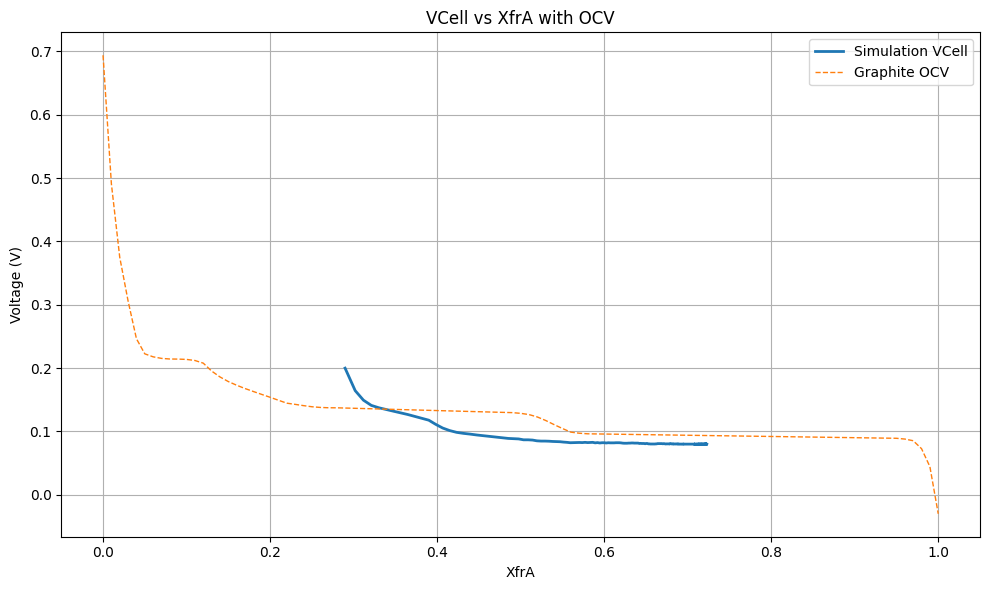

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*\d+\s*\[.*?\],\s*VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)

def load_data(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    matches = pattern.findall(text)

    data = []
    for vcell, cp_min, cp_max, xfrc in matches:
        data.append((
            float(xfrc),
            float(vcell),
            float(cp_min),
            float(cp_max)
        ))

    df = pd.DataFrame(
        data,
        columns=["XfrC_avg", "VCell", "Cp_min", "Cp_max"]
    )

    print(f"{file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df

# ============================================================
# LOAD FILES
# ============================================================

df1 = load_data(
    "../MSU_HPCC/SiGraphite-Blend-14104372.SLURMout"
)


# ============================================================
# STEP 2: LOAD Graphite OCV TABLE
# ============================================================

ticks = np.loadtxt("../inputs/materials/C_Li_X_101.txt")
ocv = np.loadtxt("../inputs/materials/C_Li_O3_101.txt")

# ============================================================
# STEP 3: INTERPOLATE OCV AT SIMULATION XfrC VALUES
# ============================================================

df1["ocv"] = np.interp(df1["XfrC_avg"], ticks, ocv)

# ============================================================
# STEP 4: PLOT
# ============================================================

plt.figure(figsize=(10,6))

# Simulation voltage
plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    linewidth=2,
    label="Simulation VCell"
)

# OCV curve
plt.plot(
    ticks,
    ocv,
    '--',
    linewidth=1,
    label="Graphite OCV"
)

plt.xlabel("XfrA")
plt.ylabel("Voltage (V)")
plt.title("VCell vs XfrA with OCV")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

# Plotting the Cell Voltage Curve Against OCV (NMC)

../MSU_HPCC/NMC-half-2D-pybamm-i0-chen2020-2C-17399455.SLURMout
Points found: 57
   XfrC_avg    VCell    Cp_min    Cp_max
0  0.300000  4.09000  0.299999  0.300311
1  0.310288  4.00101  0.300000  0.358154
2  0.321697  3.97602  0.300000  0.379423
3  0.333114  3.95602  0.300000  0.396614
4  0.344538  3.93802  0.300000  0.412197
../MSU_HPCC/NMC-half-2D-pybamm-i0-chen2020-17398277.SLURMout
Points found: 115
   XfrC_avg    VCell    Cp_min    Cp_max
0  0.300000  4.09000  0.299999  0.300311
1  0.305372  4.04201  0.300000  0.330625
2  0.311078  4.02901  0.300000  0.341120
3  0.316787  4.01801  0.300000  0.349360
4  0.322500  4.00801  0.300000  0.356805
../MSU_HPCC/NMC-half-2D-pybamm-i0-chen2020-0.5C-17399524.SLURMout
Points found: 161
   XfrC_avg    VCell    Cp_min    Cp_max
0  0.300000  4.09000  0.299999  0.300311
1  0.302740  4.06500  0.300000  0.316109
2  0.305591  4.05800  0.300000  0.321124
3  0.308442  4.05301  0.300000  0.325153
4  0.311295  4.04701  0.300000  0.328780


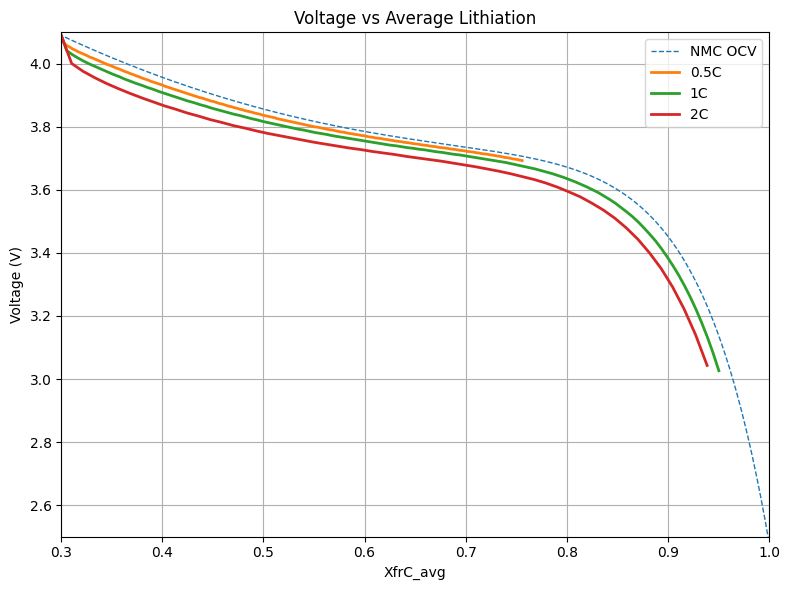

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*\d+\s*\[.*?\],\s*VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)

def load_data(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    matches = pattern.findall(text)

    data = []
    for vcell, cp_min, cp_max, xfrc in matches:
        data.append((
            float(xfrc),
            float(vcell),
            float(cp_min),
            float(cp_max)
        ))

    df = pd.DataFrame(
        data,
        columns=["XfrC_avg", "VCell", "Cp_min", "Cp_max"]
    )

    print(f"{file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df

# ============================================================
# LOAD FILES
# ============================================================

df1 = load_data(
    "../MSU_HPCC/NMC-half-2D-pybamm-i0-chen2020-2C-17399455.SLURMout"
)

df2 = load_data(
    "../MSU_HPCC/NMC-half-2D-pybamm-i0-chen2020-17398277.SLURMout"
)

df3 = load_data(
    "../MSU_HPCC/NMC-half-2D-pybamm-i0-chen2020-0.5C-17399524.SLURMout"
)
# ============================================================
# STEP 2: DEFINE OCV FUNCTION
# ============================================================

def ocv_function(c):
    return (
        1.095 * c * c
        - 8.234e-7 * np.exp(14.31 * c)
        + 4.692 * np.exp(-0.5389 * c)
    )

# Generate smooth OCV curve
c_vals = np.linspace(0.01, 1.0, 500)
ocv_vals = ocv_function(c_vals)

# Interpolated OCV at simulation points
df1["ocv"] = ocv_function(df1["XfrC_avg"])
df2["ocv"] = ocv_function(df2["XfrC_avg"])
df3["ocv"] = ocv_function(df3["XfrC_avg"])

# ============================================================
# PLOT 1: VOLTAGE VS AVERAGE LITHIATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    c_vals,
    ocv_vals,
    "--",
    linewidth=1,
    label="NMC OCV"
)

plt.plot(
    df3["XfrC_avg"],
    df3["VCell"],
    linewidth=2,
    label="0.5C"
)

plt.plot(
    df2["XfrC_avg"],
    df2["VCell"],
    linewidth=2,
    label="1C"
)

plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    linewidth=2,
    label="2C"
)


plt.xlabel("XfrC_avg")
plt.ylabel("Voltage (V)")
plt.xlim(0.3, 1.0)
plt.ylim(2.5, 4.1)
plt.title("Voltage vs Average Lithiation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
# ============================================================
# PUBLICATION-QUALITY SETTINGS
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "font.size": 10,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,

    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,

    "figure.dpi": 300,
})

# ============================================================
# VOLTAGE VS LITHIATION
# ============================================================

fig, ax = plt.subplots(figsize=(6.3, 4.8))

# Simulation
ax.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    color="black",
    linewidth=2.6,
    label="BESFEM"
)

# OCV
ax.plot(
    c_vals,
    ocv_vals,
    "--",
    color="red",
    linewidth=2,
    label="NMC OCV"
)

# Axes
ax.set_xlim(0.30, 1.00)
ax.set_ylim(2.80, 4.10)

ax.set_xlabel("Average Lithiation Fraction")
ax.set_ylabel("Voltage (V)")

# Major/minor ticks
ax.minorticks_on()

ax.grid(
    which="major",
    color="0.85",
    linewidth=0.8
)

ax.grid(
    which="minor",
    color="0.92",
    linewidth=0.5
)

# Legend
leg = ax.legend(
    loc="upper right",
    frameon=True
)
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(0.8)
plt.title("Voltage vs Average Lithiation")

plt.tight_layout()
plt.savefig(
    "3D_NMC_voltage_vs_OCV.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

NameError: name 'plt' is not defined

# Plotting the Cell Voltage Curve Against OCV (LFP)

../MSU_HPCC/3D-LFP-HALF-14073009.SLURMout
Points found: 8
   XfrC_avg    VCell    Cp_min    Cp_max
0  0.200000  3.38690  0.199957  0.200051
1  0.200981  3.40280  0.133618  0.230268
2  0.201945  3.40735  0.061384  0.263076
3  0.202778  3.40356  0.054959  0.301008
4  0.203656  3.40356  0.054475  0.353269


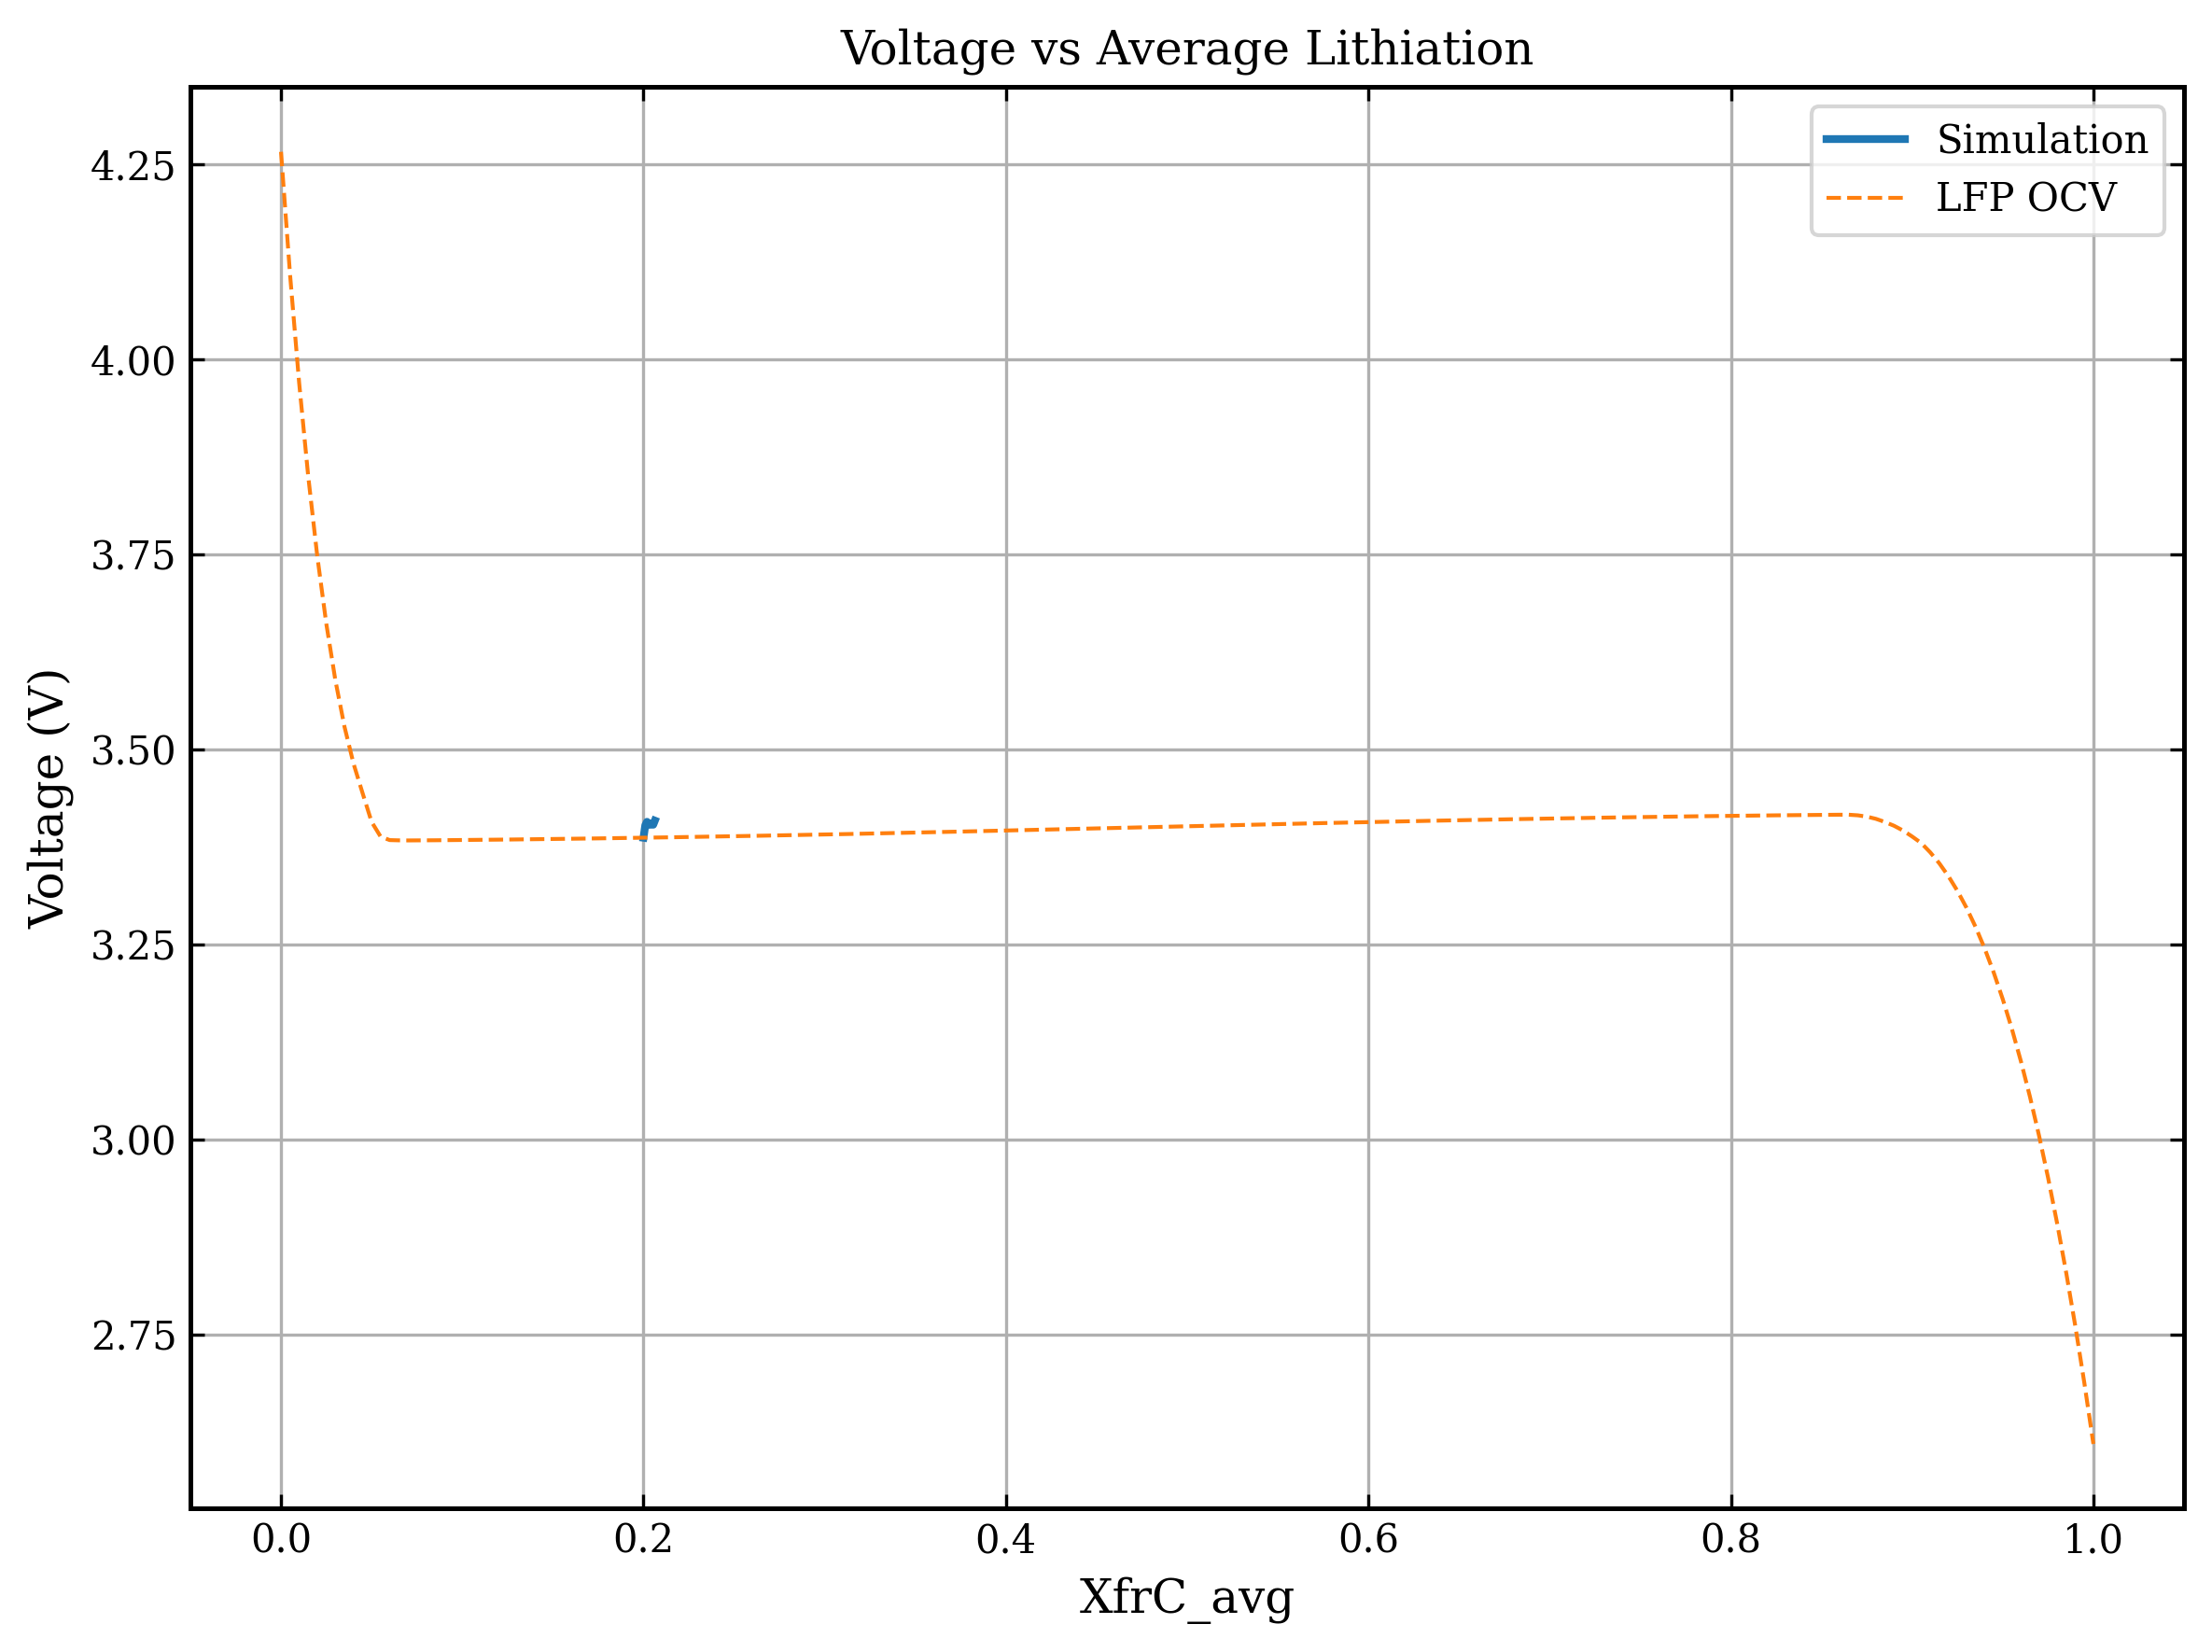

In [4]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*\d+\s*\[.*?\],\s*VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)

def load_data(file_path):
    with open(file_path, "r") as f:
        text = f.read()

    matches = pattern.findall(text)

    data = []
    for vcell, cp_min, cp_max, xfrc in matches:
        data.append((
            float(xfrc),
            float(vcell),
            float(cp_min),
            float(cp_max)
        ))

    df = pd.DataFrame(
        data,
        columns=["XfrC_avg", "VCell", "Cp_min", "Cp_max"]
    )

    print(f"{file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df

# ============================================================
# LOAD FILES
# ============================================================

df1 = load_data(
    "../MSU_HPCC/3D-LFP-HALF-14073009.SLURMout")
    # "../parameter_sweep_tool/benchmark_runs_2/20260728_081905_104093_test/logs/job_13765643/run_0004.log")

# ============================================================
# LOAD AND CALCULATE LFP OCV
# ============================================================

ticks = np.loadtxt("../inputs/materials/LFP_Chm_Pot_Ticks.txt")
chmPot = np.loadtxt("../inputs/materials/LFP_Chm_Pot.txt")

# Matches MaterialProperties.cpp:
# OCV = -chemical_potential + 3.4
ocv = -chmPot + 3.4

# ============================================================
# PLOT 1: VOLTAGE VS AVERAGE LITHIATION
# ============================================================

plt.figure(figsize=(8, 6))

plt.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    linewidth=2,
    label="Simulation"
)

plt.plot(
    ticks,
    ocv,
    "--",
    linewidth=1,
    label="LFP OCV"
)

plt.xlabel("XfrC_avg")
# plt.xlim(0.195, 0.23)
plt.ylabel("Voltage (V)")
plt.title("Voltage vs Average Lithiation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Scientific Formatting

Loaded: ../MSU_HPCC/Graphite-half-cell-13727369.SLURMout
Points found: 125
   timestep  XfrC_avg     VCell    Cp_min    Cp_max
0         0  0.030000  0.368600  0.030000  0.030002
1     10000  0.047061  0.208625  0.031250  0.052850
2     20000  0.066153  0.199626  0.037855  0.092416
3     30000  0.085202  0.183229  0.042375  0.117757
4     40000  0.104181  0.158232  0.047553  0.137770


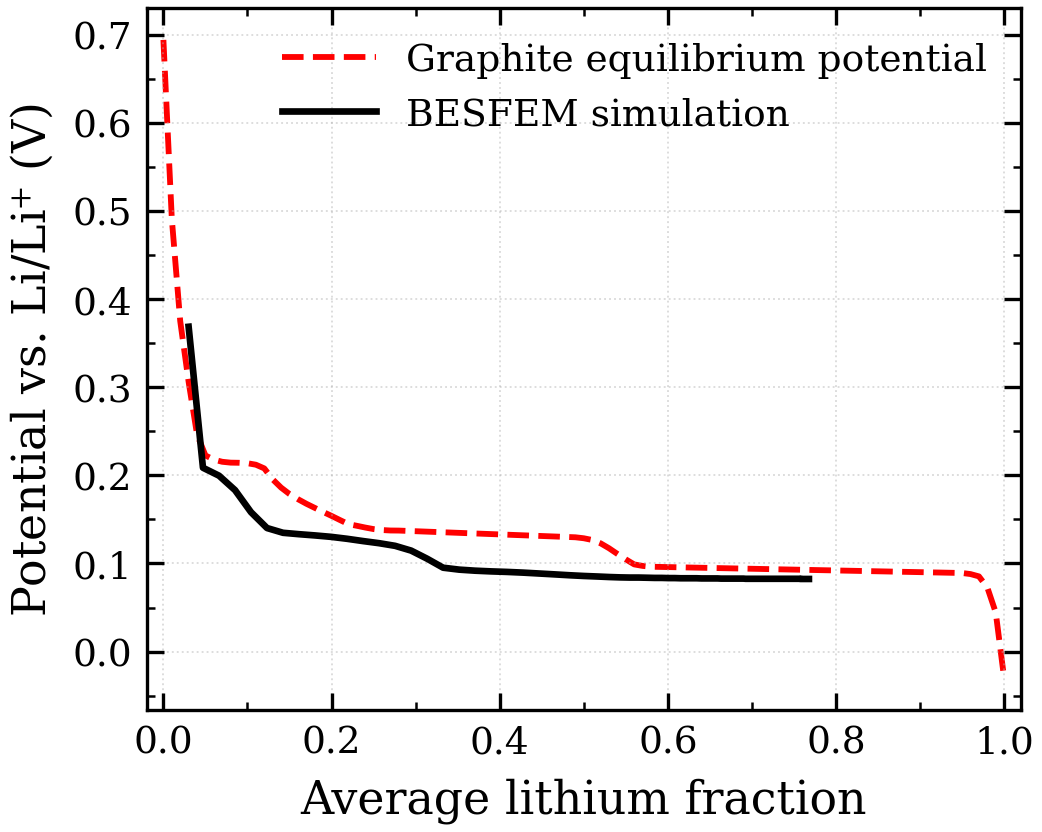

In [5]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator


# ============================================================
# PUBLICATION-QUALITY MATPLOTLIB SETTINGS
# ============================================================

plt.rcParams.update({
    # Typography
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    # Font sizes
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": True,
    "axes.spines.right": True,

    # Lines
    "lines.linewidth": 1.6,

    # Tick marks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    # Saving
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
})


# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*(\d+)\s*\[.*?\],\s*"
    r"VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)


def load_data(file_path):
    """
    Parse half-cell simulation output.

    Returns
    -------
    pandas.DataFrame
        Columns:
        timestep, XfrC_avg, VCell, Cp_min, Cp_max
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"Could not find file: {file_path}")

    text = file_path.read_text()

    matches = pattern.findall(text)

    if not matches:
        raise ValueError(
            f"No simulation data were found in {file_path}.\n"
            "Check whether the field names and their order match the parser."
        )

    data = [
        {
            "timestep": int(timestep),
            "XfrC_avg": float(xfrc),
            "VCell": float(vcell),
            "Cp_min": float(cp_min),
            "Cp_max": float(cp_max),
        }
        for timestep, vcell, cp_min, cp_max, xfrc in matches
    ]

    df = pd.DataFrame(data)

    # Remove duplicate entries and arrange data in physical order.
    df = (
        df.drop_duplicates(subset="timestep")
          .sort_values("timestep")
          .reset_index(drop=True)
    )

    print(f"Loaded: {file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df


# ============================================================
# LOAD SIMULATION DATA
# ============================================================

df1 = load_data(
    "../MSU_HPCC/Graphite-half-cell-13727369.SLURMout"
)


# ============================================================
# LOAD GRAPHITE OCV TABLE
# ============================================================

ticks = np.loadtxt("../inputs/materials/C_Li_X_101.txt")
ocv = np.loadtxt("../inputs/materials/C_Li_O3_101.txt")

if ticks.shape != ocv.shape:
    raise ValueError(
        "The graphite stoichiometry and OCV tables have different lengths."
    )

# Sort the OCV table in case its entries are not ordered.
sort_index = np.argsort(ticks)
ticks = ticks[sort_index]
ocv = ocv[sort_index]


# ============================================================
# INTERPOLATE OCV AT SIMULATION POINTS
# ============================================================

df1["OCV"] = np.interp(
    df1["XfrC_avg"],
    ticks,
    ocv
)

df1["overpotential"] = df1["VCell"] - df1["OCV"]


# ============================================================
# PUBLICATION-QUALITY PLOT
# ============================================================

# Approximately 3.5 inches wide for a single journal column.
fig, ax = plt.subplots(figsize=(3.5, 2.8), constrained_layout=True)

# Graphite equilibrium potential.
ax.plot(
    ticks,
    ocv,
    color="red",
    linestyle="--",
    linewidth=1.4,
    label="Graphite equilibrium potential",
    zorder=1
)

# Simulated voltage.
ax.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    color="black",
    linestyle="-",
    # marker="o",
    # markersize=3.5,
    # markeredgewidth=0.6,
    linewidth=1.6,
    label="BESFEM simulation",
    zorder=2
)

# Mathematical notation is preferable to variable names such as XfrC.
ax.set_xlabel(r"Average lithium fraction")
ax.set_ylabel(r"Potential vs. Li/Li$^{+}$ (V)")

# Use the data range automatically, with modest margins.
x_min = min(ticks.min(), df1["XfrC_avg"].min())
x_max = max(ticks.max(), df1["XfrC_avg"].max())
x_margin = 0.02 * (x_max - x_min)

ax.set_xlim(x_min - x_margin, x_max + x_margin)

# Minor ticks improve readability without adding visual clutter.
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True
)

# A faint major grid can be useful; remove this block if the journal
# prefers figures without gridlines.
ax.grid(
    which="major",
    linestyle=":",
    linewidth=0.45,
    alpha=0.45
)

ax.legend(
    loc="best",
    frameon=False,
    handlelength=2.5
)

# ============================================================
# SAVE VECTOR AND HIGH-RESOLUTION RASTER COPIES
# ============================================================

# fig.savefig("graphite_voltage_vs_lithiation.pdf")
# fig.savefig("graphite_voltage_vs_lithiation.svg")
fig.savefig("graphite_voltage_vs_lithiation.png", dpi=600)

plt.show()

Loaded: ../MSU_HPCC/CarbonGraphite-Blend-No-AMR-14355509.SLURMout
Points found: 466
   timestep  XfrC_avg     VCell    Cp_min    Cp_max
0         0  0.366568  0.200000  0.399928  0.402403
1      5000  0.382724  0.229595  0.400000  0.484537
2     10000  0.391829  0.219197  0.400000  0.494265
3     15000  0.400454  0.210598  0.400000  0.502315
4     20000  0.409070  0.201000  0.400000  0.511589


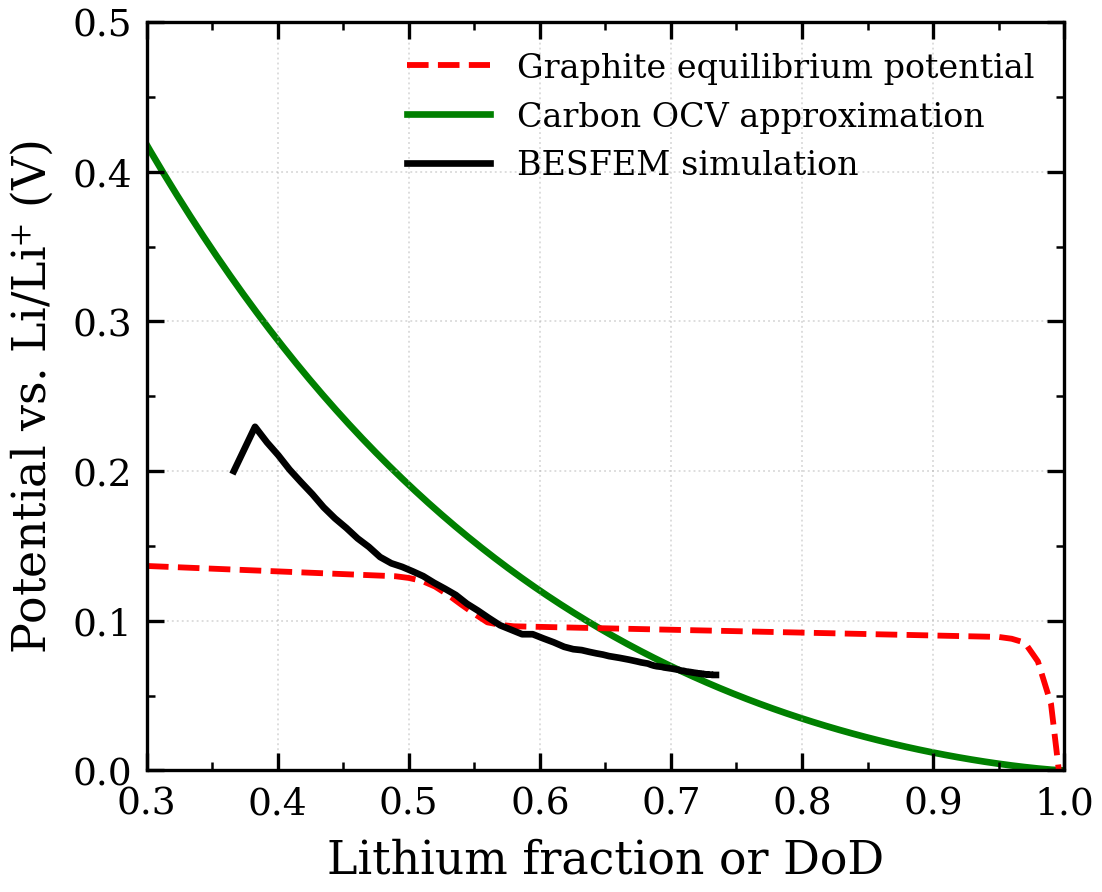

In [6]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator


# ============================================================
# PUBLICATION-QUALITY MATPLOTLIB SETTINGS
# ============================================================

plt.rcParams.update({
    # Typography
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    # Font sizes
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    # Axes
    "axes.linewidth": 0.8,
    "axes.spines.top": True,
    "axes.spines.right": True,

    # Lines
    "lines.linewidth": 1.6,

    # Tick marks
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    # Saving
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
})


# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*(\d+)\s*\[.*?\],\s*"
    r"VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"XfrC_avg\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)


def load_data(file_path):
    """
    Parse half-cell simulation output.

    Returns
    -------
    pandas.DataFrame
        Columns:
        timestep, XfrC_avg, VCell, Cp_min, Cp_max
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"Could not find file: {file_path}")

    text = file_path.read_text()

    matches = pattern.findall(text)

    if not matches:
        raise ValueError(
            f"No simulation data were found in {file_path}.\n"
            "Check whether the field names and their order match the parser."
        )

    data = [
        {
            "timestep": int(timestep),
            "XfrC_avg": float(xfrc),
            "VCell": float(vcell),
            "Cp_min": float(cp_min),
            "Cp_max": float(cp_max),
        }
        for timestep, vcell, cp_min, cp_max, xfrc in matches
    ]

    df = pd.DataFrame(data)

    df = (
        df.drop_duplicates(subset="timestep")
          .sort_values("timestep")
          .reset_index(drop=True)
    )

    print(f"Loaded: {file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df


# ============================================================
# LOAD SIMULATION DATA
# ============================================================

df1 = load_data(
    "../MSU_HPCC/CarbonGraphite-Blend-No-AMR-14355509.SLURMout"
)


# ============================================================
# LOAD GRAPHITE OCV TABLE
# ============================================================

ticks = np.loadtxt("../inputs/materials/C_Li_X_101.txt")
ocv = np.loadtxt("../inputs/materials/C_Li_O3_101.txt")

if ticks.shape != ocv.shape:
    raise ValueError(
        "The graphite stoichiometry and OCV tables have different lengths."
    )

sort_index = np.argsort(ticks)
ticks = ticks[sort_index]
ocv = ocv[sort_index]


# ============================================================
# DEFINE APPROXIMATE GREEN silicon OCV CURVE
# ============================================================

# The green curve in the supplied figure is plotted against DoD.
# Here, its horizontal coordinate is placed on the same 0-to-1 axis
# as the graphite lithium fraction for direct visual comparison.

# silicon_x = np.linspace(0.0, 1.0, 100)

# silicon_ocv = 1.1202797 * (
#     np.exp(-2.7959121 * silicon_x) - np.exp(-2.7959121)
# ) / (
#     1.0 - np.exp(-2.7959121)
# )

# ============================================================
# DIGITIZED APPROXIMATION OF GREEN silicon OCV CURVE
# ============================================================

silicon_x = np.linspace(0.0, 1.0, 100)

silicon_ocv = (
    1.12165244
    * (1.0 - silicon_x)**1.28022415
    * np.exp(-1.76785792 * silicon_x)
)


# ============================================================
# INTERPOLATE GRAPHITE OCV AT SIMULATION POINTS
# ============================================================

df1["OCV"] = np.interp(
    df1["XfrC_avg"],
    ticks,
    ocv
)

df1["overpotential"] = df1["VCell"] - df1["OCV"]


# ============================================================
# PUBLICATION-QUALITY PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(3.7, 3.0),
    constrained_layout=True
)

# Graphite equilibrium potential.
ax.plot(
    ticks,
    ocv,
    color="red",
    linestyle="--",
    linewidth=1.4,
    label="Graphite equilibrium potential",
    zorder=2
)

# Approximate green silicon OCV curve.
ax.plot(
    silicon_x,
    silicon_ocv,
    color="green",
    linestyle="-",
    linewidth=1.6,
    label="Carbon OCV approximation",
    zorder=1
)

# Simulated graphite half-cell voltage.
ax.plot(
    df1["XfrC_avg"],
    df1["VCell"],
    color="black",
    linestyle="-",
    linewidth=1.6,
    label="BESFEM simulation",
    zorder=3
)

ax.set_xlabel(r"Lithium fraction or DoD")
ax.set_ylabel(r"Potential vs. Li/Li$^{+}$ (V)")

# Both OCV curves use a normalized 0-to-1 horizontal coordinate.
ax.set_xlim(0.30, 1.0)

# Include the full green curve, which reaches approximately 1.12 V.
all_y = np.concatenate([
    ocv,
    silicon_ocv,
    df1["VCell"].to_numpy()
])

y_min = min(0.0, all_y.min())
y_max = all_y.max()
y_margin = 0.04 * (y_max - y_min)

# ax.set_ylim(
#     y_min - 0.01,
#     y_max + y_margin
# )

ax.set_ylim(0.0, 0.5)

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True
)

ax.grid(
    which="major",
    linestyle=":",
    linewidth=0.45,
    alpha=0.45
)

ax.legend(
    loc="upper right",
    frameon=False,
    handlelength=2.5
)

# ============================================================
# SAVE FIGURE
# ============================================================

fig.savefig(
    "graphite_and_silicon_ocv_overlay.png",
    dpi=600
)

plt.show()

Loaded: ../MSU_HPCC/Carbon_Graphite_EAST-SMALL-14515790.SLURMout
Points found: 229
   timestep     VCell    Cp_min    Cp_max     Xfr_0     Xfr_1     Xfr_2  \
0         0  0.526500  0.229988  0.232074  0.230000  0.020000  0.020000   
1      5000  0.432514  0.230000  0.290792  0.252351  0.017162  0.016905   
2     10000  0.388321  0.230000  0.320761  0.271031  0.018207  0.018545   
3     15000  0.353927  0.230000  0.346011  0.289104  0.020076  0.020669   
4     20000  0.325131  0.230000  0.368603  0.306682  0.022579  0.023210   

   Xfr_volume_avg  Electrode_DoD  
0        0.137014       0.122939  
1        0.148149       0.132262  
2        0.159163       0.142110  
3        0.170123       0.152003  
4        0.181035       0.161929  


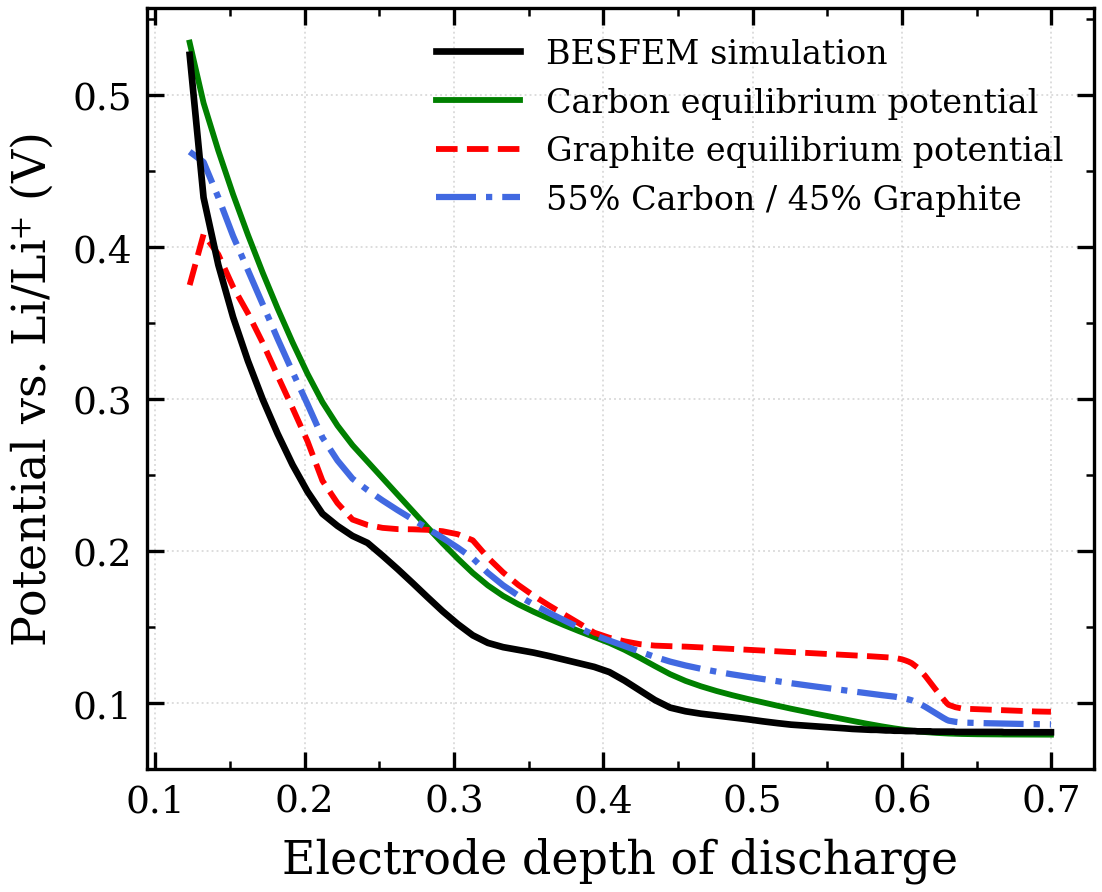

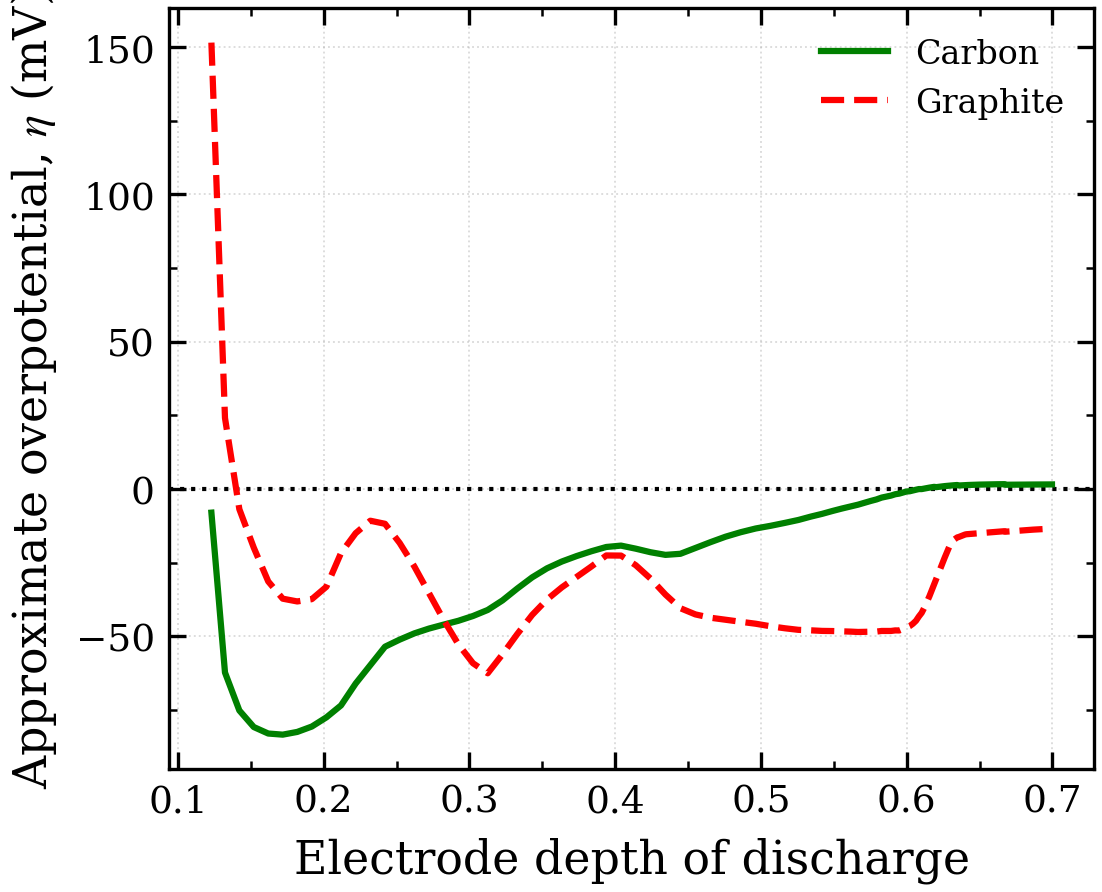

In [7]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator


# ============================================================
# PUBLICATION-QUALITY MATPLOTLIB SETTINGS
# ============================================================

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,

    "axes.linewidth": 0.8,
    "axes.spines.top": True,
    "axes.spines.right": True,

    "lines.linewidth": 1.6,

    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,

    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.03,
})


# ============================================================
# PARSER
# ============================================================

pattern = re.compile(
    r"timestep:\s*(\d+)\s*\[ANODE HALF-CELL\],\s*"
    r"VCell\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_min\s*=\s*([-+eE0-9.]+).*?"
    r"Cp_max\s*=\s*([-+eE0-9.]+).*?"
    r"Xfr_0\s*=\s*([-+eE0-9.]+).*?"
    r"Xfr_1\s*=\s*([-+eE0-9.]+).*?"
    r"Xfr_2\s*=\s*([-+eE0-9.]+).*?"
    r"Xfr_volume_avg\s*=\s*([-+eE0-9.]+).*?"
    r"Electrode_DoD\s*=\s*([-+eE0-9.]+)",
    re.DOTALL
)


def load_data(file_path):
    """
    Parse the graphite-carbon anode half-cell simulation output.

    Returns
    -------
    pandas.DataFrame
        Columns:
        timestep, VCell, Cp_min, Cp_max,
        Xfr_0, Xfr_1, Xfr_2,
        Xfr_volume_avg, Electrode_DoD
    """
    file_path = Path(file_path)

    if not file_path.exists():
        raise FileNotFoundError(f"Could not find file: {file_path}")

    text = file_path.read_text()

    matches = pattern.findall(text)

    if not matches:
        raise ValueError(
            f"No simulation data were found in {file_path}.\n"
            "Check that the log contains Xfr_volume_avg and Electrode_DoD."
        )

    data = [
        {
            "timestep": int(timestep),
            "VCell": float(vcell),
            "Cp_min": float(cp_min),
            "Cp_max": float(cp_max),
            "Xfr_0": float(xfr_0),
            "Xfr_1": float(xfr_1),
            "Xfr_2": float(xfr_2),
            "Xfr_volume_avg": float(xfr_volume_avg),
            "Electrode_DoD": float(electrode_dod),
        }
        for (
            timestep,
            vcell,
            cp_min,
            cp_max,
            xfr_0,
            xfr_1,
            xfr_2,
            xfr_volume_avg,
            electrode_dod,
        ) in matches
    ]

    df = pd.DataFrame(data)

    df = (
        df.drop_duplicates(subset="timestep")
          .sort_values("timestep")
          .reset_index(drop=True)
    )

    print(f"Loaded: {file_path}")
    print(f"Points found: {len(df)}")
    print(df.head())

    return df


# ============================================================
# LOAD SIMULATION DATA
# ============================================================

df1 = load_data(
    "../MSU_HPCC/Carbon_Graphite_EAST-SMALL-14515790.SLURMout"
)


# ============================================================
# OPTIONAL: FILTER AND SORT
# ============================================================

df1 = (
    df1[np.isfinite(df1["Electrode_DoD"]) & np.isfinite(df1["VCell"])]
    .sort_values("Electrode_DoD")
    .reset_index(drop=True)
)


carbon_x = df1["Xfr_0"]

graphite_x = (
    df1["Xfr_1"] + df1["Xfr_2"]
) / 2.0

# Particle volumes printed by BESFEM
V_graphite_1 = 2.07330e-6
V_graphite_2 = 4.06046e-7

df1["Xfr_graphite_avg"] = (
    V_graphite_1 * df1["Xfr_1"]
    + V_graphite_2 * df1["Xfr_2"]
) / (
    V_graphite_1 + V_graphite_2
)

df1["Carbon_OCV"] = (
    1.12165244
    * (1.0 - carbon_x) ** 1.28022415
    * np.exp(-1.76785792 * carbon_x)
)

# df1["Graphite_OCV"] = np.interp(
#     graphite_x,
#     ticks,
#     ocv
# )

df1["Graphite_OCV"] = np.interp(
    df1["Xfr_graphite_avg"],
    ticks,
    ocv
)

df1["Eta_carbon"] = (
    df1["VCell"] - df1["Carbon_OCV"]
)

df1["Eta_graphite"] = (
    df1["VCell"] - df1["Graphite_OCV"]
)

# ============================================================
# COMPOSITE ELECTRODE OCV (55% Carbon / 45% Graphite)
# ============================================================

carbon_fraction = 0.55
graphite_fraction = 0.45

df1["Blend_OCV"] = (
    carbon_fraction * df1["Carbon_OCV"]
    + graphite_fraction * df1["Graphite_OCV"]
)


# ============================================================
# PUBLICATION-QUALITY PLOT
# ============================================================

fig, ax = plt.subplots(
    figsize=(3.7, 3.0),
    constrained_layout=True
)

ax.plot(
    df1["Electrode_DoD"],
    df1["VCell"],
    color="black",
    linestyle="-",
    linewidth=1.6,
    label="BESFEM simulation",
    zorder=3
)

ax.plot(
    df1["Electrode_DoD"],
    df1["Carbon_OCV"],
    color="green",
    linestyle="-",
    linewidth=1.4,
    label="Carbon equilibrium potential"
)

ax.plot(
    df1["Electrode_DoD"],
    df1["Graphite_OCV"],
    color="red",
    linestyle="--",
    linewidth=1.4,
    label="Graphite equilibrium potential"
)

ax.plot(
    df1["Electrode_DoD"],
    df1["Blend_OCV"],
    color="royalblue",
    linestyle="-.",
    linewidth=1.5,
    label="55% Carbon / 45% Graphite"
)

ax.set_xlabel(r"Electrode depth of discharge")
ax.set_ylabel(r"Potential vs. Li/Li$^{+}$ (V)")

# Let the data determine the DoD range.
dod_min = df1["Electrode_DoD"].min()
dod_max = df1["Electrode_DoD"].max()

dod_margin = 0.02 * max(dod_max - dod_min, 1.0e-6)

# ax.set_xlim(
#     max(0.0, dod_min - dod_margin),
#     min(1.0, dod_max + dod_margin)
# )

# Adjust this based on the full voltage range of your simulation.
v_min = df1["VCell"].min()
v_max = df1["VCell"].max()
v_margin = 0.05 * max(v_max - v_min, 1.0e-6)

# ax.set_ylim(
#     max(0.0, v_min - v_margin),
#     v_max + v_margin
# )

ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))

ax.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True
)

ax.grid(
    which="major",
    linestyle=":",
    linewidth=0.45,
    alpha=0.45
)

ax.legend(
    loc="upper right",
    frameon=False,
    handlelength=2.5
)

# ============================================================
# SAVE FIGURE
# ============================================================

fig.savefig(
    "carbon_graphite_voltage_vs_electrode_DoD.png",
    dpi=600
)

plt.show()

fig_eta, ax_eta = plt.subplots(
    figsize=(3.7, 3.0),
    constrained_layout=True
)

ax_eta.axhline(
    0.0,
    color="black",
    linestyle=":",
    linewidth=1.0
)

ax_eta.plot(
    df1["Electrode_DoD"],
    1000.0 * df1["Eta_carbon"],
    color="green",
    linestyle="-",
    linewidth=1.5,
    label="Carbon"
)

ax_eta.plot(
    df1["Electrode_DoD"],
    1000.0 * df1["Eta_graphite"],
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Graphite"
)

ax_eta.set_xlabel(r"Electrode depth of discharge")
ax_eta.set_ylabel(r"Approximate overpotential, $\eta$ (mV)")

ax_eta.xaxis.set_minor_locator(AutoMinorLocator(2))
ax_eta.yaxis.set_minor_locator(AutoMinorLocator(2))

ax_eta.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True
)

ax_eta.grid(
    which="major",
    linestyle=":",
    linewidth=0.45,
    alpha=0.45
)

ax_eta.legend(
    frameon=False
)

fig_eta.savefig(
    "carbon_graphite_overpotential_vs_DoD.png",
    dpi=600
)

plt.show()